# DDA - TMT

This tutorial demonstrates how to analyze Tandem Mass Tag (TMT) labeled data from data-dependent acquisition (DDA) using `msmu` package.

## Data Preparation

Original dataset is from [PXD013361](https://www.ebi.ac.uk/pride/archive/projects/PXD013361) (Magnusson _et al_., 2019) and the search was performed with [`Sage` v0.14.7](https://github.com/lazear/sage/tree/v0.14.7).

For demonstration purposes, the example dataset has been trimmed to include only 5,000 PSMs.


In [1]:
base_dir = "https://raw.githubusercontent.com/bertis-informatics/msmu/refs/heads/dev/data/sage_tmt"
sage_idents = f"{base_dir}/sage/results.sage.tsv"
sage_quants = f"{base_dir}/sage/tmt.tsv"
sdrf = f"{base_dir}/meta.sdrf.tsv"

## Load Required Packages

> If you haven't installed the `msmu` package yet, please follow the [installation guide](../../installation/).


In [2]:
import msmu as mm
import plotly.io as pio

pio.renderers.default = "png"

## Read Data

You can read data from various proteomics software outputs. Below are examples for `Sage`, `MaxQuant`, and `FragPipe` formats.

For this tutorial, we will use the `Sage` output as an example.

`read_sage()` function reads the `Sage` output files (`tmt.tsv`, `results.sage.tsv`) and creates modalities at MuData object.


In [4]:
# Sage format
mdata = mm.read_sage(identification_file=sage_idents, quantification_file=sage_quants, label="tmt")

# MaxQuant format
# mdata = mm.read_maxquant(identification_file="path_to_maxquant_output", label="tmt", acquisition="dda")

# FragPipe format
# mdata = mm.read_fragpipe(identification_file="path_to_fragpipe_output", label="tmt", acquisition="dda")

# Sample metadata from the SDRF: TMT channels in obs already line up with comment[label]
mdata = mm.pp.attach_sdrf(mdata, sdrf)
mdata = mm.pp.apply_sdrf_to_obs(mdata)

mdata.obs

# Without an SDRF, add_meta() joins any table onto obs instead -- here a CSV whose "tag" column
# holds the same channel names as obs:
# mdata = mm.pp.add_meta(mdata, f"{base_dir}/meta.csv", format="csv", metadata_on="tag")

INFO - Validating SDRF metadata for https://raw.githubusercontent.com/bertis-informatics/msmu/refs/heads/dev/data/sage_tmt/meta.sdrf.tsv.
INFO - SDRF validation succeeded for https://raw.githubusercontent.com/bertis-informatics/msmu/refs/heads/dev/data/sage_tmt/meta.sdrf.tsv.
WARNING - apply_sdrf_to_obs: psm columns not projectable under 'comment[label]'; kept only in uns['sdrf']: ['assay name', 'comment[data file]', 'comment[fraction identifier]']


,source name,characteristics[organism],characteristics[organism part],characteristics[disease],characteristics[biological replicate],technology type,comment[proteomexchange accession number],comment[proteomics data acquisition method],comment[technical replicate],comment[instrument],comment[cleavage agent details],factor value[condition],factor value[time point]
TMT126,t0h,Homo sapiens,not available,not available,1,proteomic profiling by mass spectrometry,PXD013361,data-dependent acquisition,1,Q Exactive,NT=Trypsin;AC=MS:1001251,t0,t0h
TMT127,t1h,Homo sapiens,not available,not available,1,proteomic profiling by mass spectrometry,PXD013361,data-dependent acquisition,1,Q Exactive,NT=Trypsin;AC=MS:1001251,t1,t1h
TMT128,t2h,Homo sapiens,not available,not available,1,proteomic profiling by mass spectrometry,PXD013361,data-dependent acquisition,1,Q Exactive,NT=Trypsin;AC=MS:1001251,t2,t2h
TMT129,t6h,Homo sapiens,not available,not available,1,proteomic profiling by mass spectrometry,PXD013361,data-dependent acquisition,1,Q Exactive,NT=Trypsin;AC=MS:1001251,t6,t6h
TMT130,t24h,Homo sapiens,not available,not available,1,proteomic profiling by mass spectrometry,PXD013361,data-dependent acquisition,1,Q Exactive,NT=Trypsin;AC=MS:1001251,t24,t24h
TMT131,t120h,Homo sapiens,not available,not available,1,proteomic profiling by mass spectrometry,PXD013361,data-dependent acquisition,1,Q Exactive,NT=Trypsin;AC=MS:1001251,t120,t120h


In [5]:
mdata

MuData object with n_obs × n_vars = 6 × 3805
  obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[disease]', 'characteristics[biological replicate]', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[technical replicate]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]', 'factor value[time point]'
  uns:	'_cmd', 'sdrf'
  1 modality
    psm:	6 × 3805
      obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[disease]', 'characteristics[biological replicate]', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[technical replicate]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]', 'factor value[time point]'
      var:	'proteins', 'peptide', 'stripped_peptide', 'filename', 'scan_num', 'charge', 'peptide_length', 'expmass', 'calcmass', 'rt', 'missed_cleavages', 'semi_enzymatic', 'contaminant', 'PEP', 'score', 'q_value', 'decoy'
      uns:	'level', 'search_engine', 'quantification', 'label', 'acquisition', 'identification_file', 'quantification_file', 'decoy'
      varm:	'search_result'
      layers:	None

### Removing Blank Channels

If your TMT data contains blank channels, you can remove them by subsetting `MuData` object.


In [6]:
mdata = mm.pp.add_filter(
    mdata,
    modality="psm",
    column="factor value[condition]",
    keep="not_contains",
    value="BLANK",
    on="obs",
)
mdata = mm.pp.apply_filter(mdata, modality="psm")

INFO - Applying obs filters for psm: ['factor value[condition]_not_contains_BLANK']


### Saving Raw MuData Object

After reading the search output, saving the MuData object as an `h5mu` file is recommended for future use.


In [6]:
mdata.write_h5mu("dda_tmt_PXD013361_raw.h5mu")

## Handling PSM level

### Filtering - PSM

You can filter the data based on the column values, such as q-value.
You can also filter on the flags the reader records, such as `contaminant`, or on string containment.

Filtering is split into two steps: first, you mark a filter condition using `mm.pp.add_filter()`, and then you apply the filter using `mm.pp.apply_filter()`.

Here, we keep protein groups with q-value < 0.01.


In [7]:
mdata = mm.pp.add_filter(mdata, modality="psm", column="q_value", keep="lt", value=0.01)
mdata = mm.pp.apply_filter(mdata, modality="psm")

mdata

INFO - Applying var filters for psm: ['q_value_lt_0.01']
INFO - Applying obs filters for psm: ['factor value[condition]_not_contains_BLANK']


MuData object with n_obs × n_vars = 6 × 2310
  obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[disease]', 'characteristics[biological replicate]', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[technical replicate]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]', 'factor value[time point]'
  uns:	'_cmd', 'sdrf'
  1 modality
    psm:	6 × 2310
      obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[disease]', 'characteristics[biological replicate]', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[technical replicate]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]', 'factor value[time point]'
      var:	'proteins', 'peptide', 'stripped_peptide', 'filename', 'scan_num', 'charge', 'peptide_length', 'expmass', 'calcmass', 'rt', 'missed_cleavages', 'semi_enzymatic', 'contaminant', 'PEP', 'score', 'q_value', 'decoy'
      uns:	'level', 'search_engine', 'quantification', 'label', 'acquisition', 'identification_file', 'quantification_file', 'decoy', 'filter', 'decoy_filter'
      obsm:	'filter'
      varm:	'search_result', 'filter'
      layers:	None

### Normalization

Here, we log2 transform and normalize the data at the PSM level.

Median centering normalization is applied using `mm.pp.normalize()` function.

Optionally, if you need to correct batch effects using Global Internal Standard (GIS) channels, you can scale the data using `mm.pp.scale_feature()` function. Make sure to have GIS channels in each TMT batch. The example code below assumes that the GIS channels are named with prefix "POOLED\_".


In [8]:
mdata = mm.pp.log2_transform(mdata, modality="psm")
mdata = mm.pp.normalize(mdata, modality="psm", method="median", group_var="filename")

# GIS-based scaling (if needed)
# mdata = mm.pp.correct_batch_effect(mdata=mdata, modality="psm", method="gis", category="batch", gis_samples=["POOLED_1", "POOLED_2"])

### Computing precursor isolation purity

For TMT data, it is recommended to compute precursor isolation purity to exclude low-purity features from quantification aggregation. `compute_precursor_isolation_purity()` function calculates precursor isolation purity using mzML files.

For demonstration purposes, we will skip this step in the tutorial.


In [9]:
# Computing precursor isolation purity
# mdata = mm.tl.compute_precursor_isolation_purity(mdata, mzml_paths=["path/to/sample1.mzML", "path/to/sample2.mzML", ...])

## Handling peptide level

### Summarization - peptide

You can summarize psm-level data to peptide-level data using the `mm.pp.to_peptide()` function.

If isolation purity was calculated and `purity_threshold` parameter is set, features below this cutoff are excluded from quantification aggregation.


In [9]:
mdata = mm.pp.to_peptide(mdata, purity_threshold=0.7)

# If precursor purity is computed, filter low-purity features
# mdata = mm.pp.to_peptide(mdata, purity_threshold=0.7)

WARNING - Purity column not found in psm modality for TMT data. Skipping purity filtering.
INFO - Peptide-level identifications: 2242 (2189 at 1% FDR)
INFO - Building new peptide quantification data.


### Filtering - peptide


In [10]:
mdata = mm.pp.add_filter(mdata, modality="peptide", column="q_value", keep="lt", value=0.01)
mdata = mm.pp.apply_filter(mdata, modality="peptide", on="var")

mdata

INFO - Applying var filters for peptide: ['q_value_lt_0.01']


MuData object with n_obs × n_vars = 6 × 4499
  obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[disease]', 'characteristics[biological replicate]', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[technical replicate]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]', 'factor value[time point]'
  uns:	'_cmd', 'sdrf'
  2 modalities
    psm:	6 × 2310
      obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[disease]', 'characteristics[biological replicate]', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[technical replicate]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]', 'factor value[time point]'
      var:	'proteins', 'peptide', 'stripped_peptide', 'filename', 'scan_num', 'charge', 'peptide_length', 'expmass', 'calcmass', 'rt', 'missed_cleavages', 'semi_enzymatic', 'contaminant', 'PEP', 'score', 'q_value', 'decoy'
      uns:	'level', 'search_engine', 'quantification', 'label', 'acquisition', 'identification_file', 'quantification_file', 'decoy', 'filter', 'decoy_filter'
      obsm:	'filter'
      varm:	'search_result', 'filter'
      layers:	None
    peptide:	6 × 2189
      obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[disease]', 'characteristics[biological replicate]', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[technical replicate]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]', 'factor value[time point]'
      var:	'peptide', 'proteins', 'stripped_peptide', 'count_psm', 'PEP', 'q_value'
      uns:	'level', 'decoy', 'filter', 'decoy_filter'
      varm:	'filter'
      layers:	None

### Protein inference

You can infer protein-level data from peptide-level data using the `mm.pp.infer_protein()` function.


In [11]:
mdata = mm.pp.infer_protein(mdata)

INFO - Starting protein inference
INFO - Initial proteins: 1772
INFO - Removed indistinguishable: 205
INFO - Removed subsettable: 68
INFO - Removed subsumable: 0
INFO - Total protein groups: 1499


## Handling protein level

### Summarization - protein

You can summarize peptide-level data to protein-level data using the `mm.pp.to_protein()` function.

As default, top 3 peptides within protein group can be used for protein group quantification aggregation. If top_n is None, all peptides will be used.


In [14]:
mdata = mm.pp.to_protein(mdata, agg_method="median_polish")

INFO - Applying var filters for peptide: ['q_value_lt_0.01', 'peptide_type_eq_unique']
INFO - Protein-level identifications: 1479 (1446 at 1% FDR)


### Filtering - protein


In [15]:
mdata = mm.pp.add_filter(mdata, modality="protein", column="q_value", keep="lt", value=0.01)
mdata = mm.pp.apply_filter(mdata, modality="protein", on="var")

mdata

INFO - Applying var filters for protein: ['q_value_lt_0.01']


MuData object with n_obs × n_vars = 6 × 5945
  obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[disease]', 'characteristics[biological replicate]', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[technical replicate]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]', 'factor value[time point]'
  uns:	'_cmd', 'sdrf'
  3 modalities
    psm:	6 × 2310
      obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[disease]', 'characteristics[biological replicate]', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[technical replicate]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]', 'factor value[time point]'
      var:	'proteins', 'peptide', 'stripped_peptide', 'filename', 'scan_num', 'charge', 'peptide_length', 'expmass', 'calcmass', 'rt', 'missed_cleavages', 'semi_enzymatic', 'contaminant', 'PEP', 'score', 'q_value', 'decoy'
      uns:	'level', 'search_engine', 'quantification', 'label', 'acquisition', 'identification_file', 'quantification_file', 'decoy', 'filter', 'decoy_filter'
      obsm:	'filter'
      varm:	'search_result', 'filter'
      layers:	None
    peptide:	6 × 2189
      obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[disease]', 'characteristics[biological replicate]', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[technical replicate]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]', 'factor value[time point]'
      var:	'peptide', 'proteins', 'stripped_peptide', 'count_psm', 'PEP', 'q_value', 'protein_group', 'peptide_type'
      uns:	'level', 'decoy', 'filter', 'decoy_filter'
      varm:	'filter'
      layers:	None
    protein:	6 × 1446
      obs:	'source name', 'characteristics[organism]', 'characteristics[organism part]', 'characteristics[disease]', 'characteristics[biological replicate]', 'technology type', 'comment[proteomexchange accession number]', 'comment[proteomics data acquisition method]', 'comment[technical replicate]', 'comment[instrument]', 'comment[cleavage agent details]', 'factor value[condition]', 'factor value[time point]'
      var:	'count_psm', 'count_stripped_peptide', 'PEP', 'q_value'
      uns:	'level', 'decoy', 'filter', 'decoy_filter'
      varm:	'filter'
      layers:	None

## Visualization

### ID plot


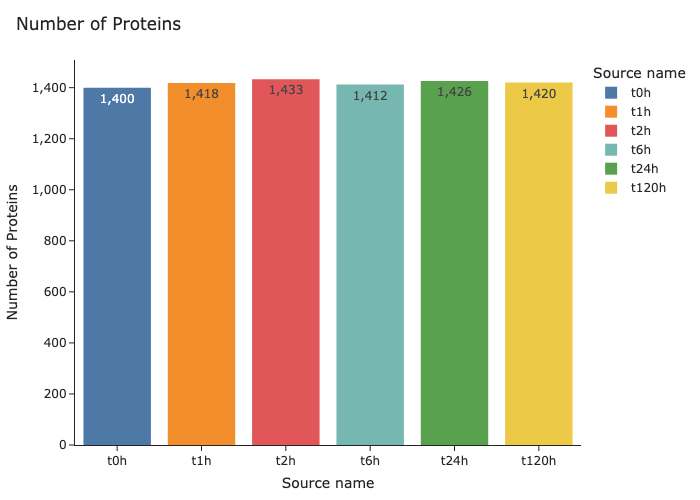

In [16]:
mm.pl.plot_id(mdata, modality="protein")

### Intensity distribution plot


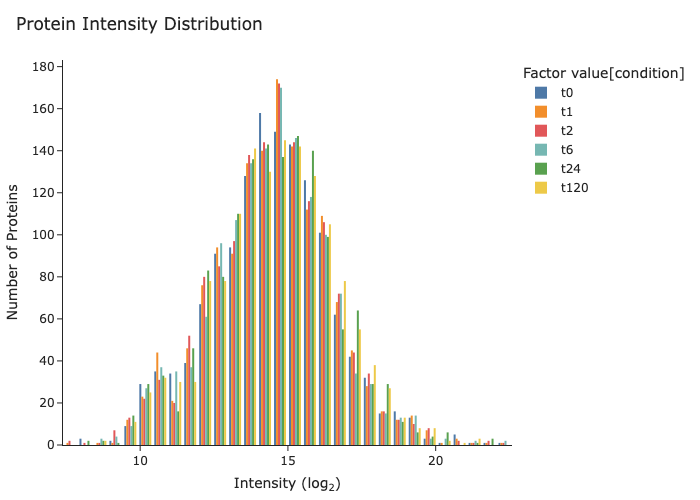

In [17]:
mm.pl.plot_intensity(mdata, modality="protein", groupby="factor value[condition]")

## Saving Processed MuData Object

You can save MuData object into an `h5mu` file.
This allows you to easily reload the processed data in future sessions without repeating the entire analysis pipeline.


In [17]:
mdata.write_h5mu("dda_tmt_PXD013361.h5mu")

## Citation

> Magnusson, R., Rundquist, O., Kim, M. J., Hellberg, S., Na, C. H., Benson, M., ... & Gustafsson, M. (2019). A validated strategy to infer protein biomarkers from RNA-Seq by combining multiple mRNA splice variants and time-delay. _BioRxiv_, 599373.

> Lazear, M. R. (2023). Sage: an open-source tool for fast proteomics searching and quantification at scale. _Journal of Proteome Research_, 22(11), 3652-3659.
